## Experiment 16 — Image Segmentation Using Thresholding\n\n*This cell also opens an upload dialog — run it in Colab and select an image when prompted.*

Saving images.jpeg to images (1).jpeg


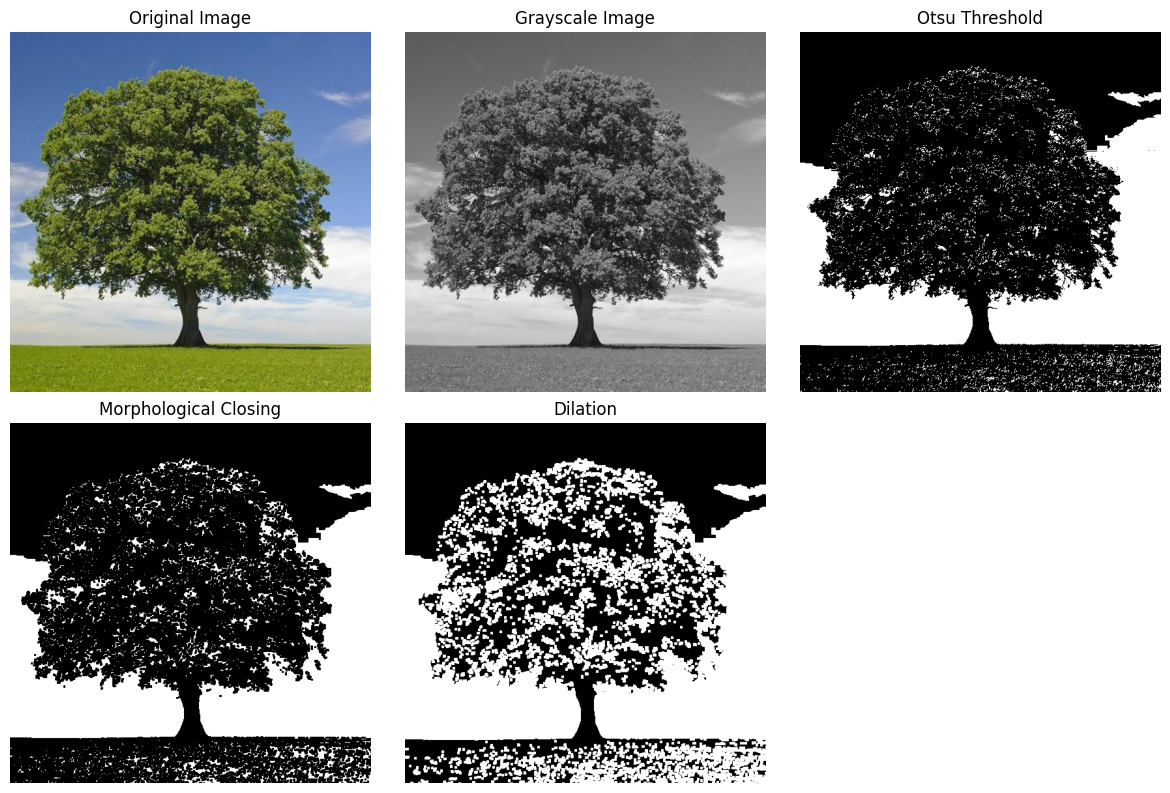

Saved output as dilation.png


In [11]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()

image_path = next(iter(uploaded))
img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError("The image could not be loaded.")

rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

ret, thresh = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

kernel = np.ones((2, 2), np.uint8)

closing = cv2.morphologyEx(
    thresh,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=2
)

sure_bg = cv2.dilate(
    closing,
    kernel,
    iterations=3
)

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(rgb_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(thresh, cmap="gray")
plt.title("Otsu Threshold")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(closing, cmap="gray")
plt.title("Morphological Closing")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(sure_bg, cmap="gray")
plt.title("Dilation")
plt.axis("off")

plt.tight_layout()
plt.show()

cv2.imwrite("dilation.png", sure_bg)
print("Saved output as dilation.png")